# Project Title :
Retail Demand Forecasting using Machine Learning

# Problem Statement:
Build a machine learning model to predict weekly sales of Walmart stores
using historical sales data.

The model will help retailers forecast product demand and optimize
inventory management.

### Step1: Data Gathering

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import pandas as pd 
path = r"https://raw.githubusercontent.com/samrudhi-shirode/Datasets/refs/heads/main/Walmart.csv"
df = pd.read_csv(path)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Step2 : Perform data quality checks

In [3]:
df.shape

(6435, 8)

In [4]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

In [7]:
# drop duplicated data for future missing cases
df = df.drop_duplicates()

In [8]:
# handle missing values
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# Step3 : Data Cleaning

In [9]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

# Step4: Feature Engineering

In [10]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [11]:
df = df.drop('Date', axis=1)

# Step5: Exploratory Data Analysis

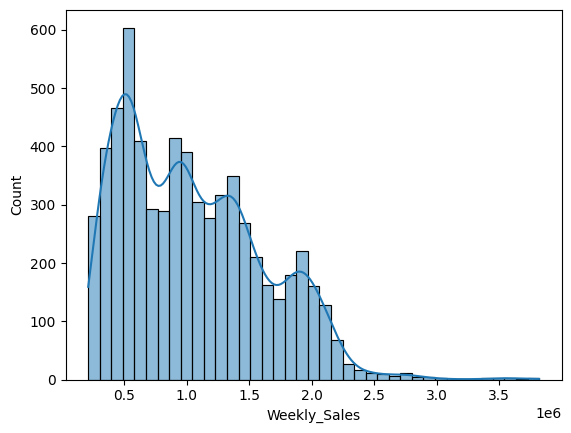

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Weekly_Sales'], kde=True)
plt.show()

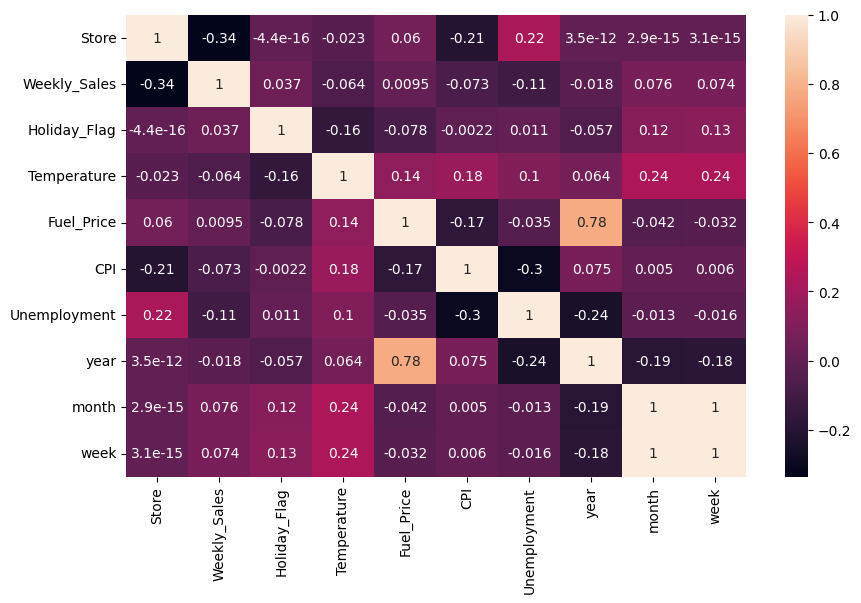

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

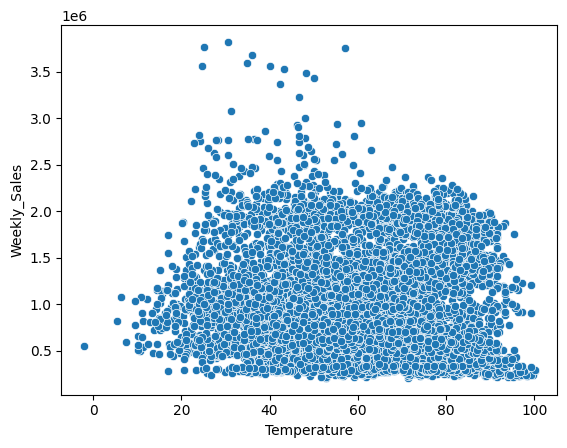

In [14]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.show()

# Step 6: Separate X and Y features

In [15]:
X = df.drop(columns='Weekly_Sales')
Y = df[['Weekly_Sales']]

In [16]:
X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,0,46.50,2.625,211.350143,8.106,2010,3,9


In [17]:
Y.head()

,Weekly_Sales
0,1643690.90
1,1641957.44
2,1611968.17
3,1409727.59
4,1554806.68


# Step7: Build Machine Learning Pipeline

In [18]:
cat = X.select_dtypes(include='object').columns
con = X.select_dtypes(exclude='object').columns

In [19]:
cat = ['Store', 'Holiday_Flag']
con = ['Temperature','Fuel_Price','CPI','Unemployment','year','month','week']

In [20]:
cat, con

(['Store', 'Holiday_Flag'],
 ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week'])

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Build the numerical pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

# Build the categorical pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False,handle_unknown='ignore')
)

# combine both the pipelines
pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform='pandas')

# Apply fit and transform on X
X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Store_1,cat__Store_2,cat__Store_3,cat__Store_4,cat__Store_5,cat__Store_6,cat__Store_7,cat__Store_8,cat__Store_9,cat__Store_10,...,cat__Store_45,cat__Holiday_Flag_0,cat__Holiday_Flag_1,con__Temperature,con__Fuel_Price,con__CPI,con__Unemployment,con__year,con__month,con__week
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.995136,-1.713800,1.004175,0.056964,-1.210899,-1.373525,-1.473530
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-1.201170,-1.766089,1.007880,0.056964,-1.210899,-1.373525,-1.402749
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-1.124178,-1.840166,1.009074,0.056964,-1.210899,-1.373525,-1.331968
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.760907,-1.737766,1.009849,0.056964,-1.210899,-1.373525,-1.261187
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.767955,-1.598328,1.010624,0.056964,-1.210899,-1.064698,-1.190406


# Step8: Splitting of data

In [22]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.8,random_state=21)

# Step9 : Train the model

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = model.predict(xtest)

# Step 10: Model Evaluation

In [27]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np 

mae = mean_absolute_error(ytest,y_pred)
mse = mean_squared_error(ytest,y_pred)
rmse = mse**(1/2)
r2 = r2_score(ytest,y_pred)

print(f"MAE: {mae} %")
print(f"MSE: {mse} %")
print(f"RMSE: {rmse} %")
print(f"R2 score: {r2*100} %")


MAE: 62303.18528818961 %
MSE: 18706501688.615723 %
RMSE: 136771.71377377605 %
R2 score: 94.38618798183802 %


# Step11: Save the model

In [28]:
import joblib

joblib.dump(model,"model.joblib")
joblib.dump(pre,"pre.joblib")

['pre.joblib']

In [29]:
model1 = joblib.load("model.joblib")
pre1 = joblib.load("pre.joblib")

In [30]:
# Predict with sample data

In [31]:
model1.predict(xtest[:5])

array([ 303991.1493,  502417.0684,  318294.4845, 1004333.5769,
        464092.8176])